# Михельсон Владимир 316 Практикум 2

<p>Дальнейший анализ будем проводить с использованием датасета из предыдущего задания и с использованием синтетических нормальных данных, там, где нормальность требуется</p>

## 1.Критерии Стьюдента, Уилкоксона-Манна-Уитни, Фишера, Левене, Бартлетта, Флигнера-Килина

### а. Критерий Стьюдента

<b>Критерий Стьюдента</b> (t-критерий) - это статистический метод, предназначенный для проверки гипотез о значимости различий между средними значениями. Он применяется в тех случаях, когда данные имеют количественный характер (например, рост, вес, концентрация вещества, баллы по тесту), а распределение признака в генеральной совокупности предполагается нормальным или близким к нему.

Ключевой особенностью t-критерия является его эффективность при работе с малыми выборками (объемом, как правило, до 30-60 наблюдений).

In [29]:
import numpy as np
from scipy import stats
import statsmodels.stats.power as smp

n = 100
mean1, mean2 = 10, 30 
std1, std2 = 100, 100

#Генерируем две выборки из нормальных распределений с заданными параметрами
np.random.seed(41)
sample1 = np.random.normal(loc=mean1, scale=std1, size=n)
sample2 = np.random.normal(loc=mean2, scale=std2, size=n)

t_stat, p_value = stats.ttest_ind(sample1, sample2) #двухсторонний t-тест

pooled_std = np.sqrt((std1**2 + std2**2) / 2) #объединенное стандартное отклонение
effect_size = (mean2 - mean1) / pooled_std #размер эффекта Коэна

analysis = smp.TTestIndPower() #
desired_power = 0.8 #целевая мощность теста 80%

print("Двухсторонний t-тест")
print(f"t-статистика: {t_stat:.4f}") #t-статистика показывает величину различия относительно вариабельности данных
print(f"p-значение: {p_value:.4f}") #p-значение показывает вероятность получить такие данные при условии, что нулевая гипотеза верна

power = analysis.solve_power(effect_size=effect_size, nobs1=n, alpha=0.1, ratio=1, alternative='two-sided') #рассчет мощности теста
#Необходимый размер выборки для достижения мощности 80%
required_sample_size = analysis.solve_power(effect_size=effect_size, power=desired_power, alpha=0.1, ratio=1, alternative='two-sided')

print(f"Мощность {power:.4f}")
print(f"Необходимый обьём выборки для мощности 0.8: {required_sample_size:.4f}")

#Проводится односторонний t-тест с альтернативной гипотезой: mean1 < mean2
t_stat, p_value = stats.ttest_ind(sample1, sample2, alternative='greater')
print("\n Односторонний t-тест (Средние sample 1 < sample2)")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-значение: {p_value:.4f}")

#Анализ мощности для одностороннего теста
power = analysis.solve_power(effect_size=effect_size, nobs1=n, alpha=0.1, ratio=1, alternative='larger')
required_sample_size = analysis.solve_power(effect_size=effect_size, power=desired_power, alpha=0.1, ratio=1, alternative='larger')

print(f"Мощность {power:.4f}")
print(f"Необходимый обьём выборки для мощности 0.8: {required_sample_size:.4f}")

Двухсторонний t-тест
t-статистика: -2.9709
p-значение: 0.0033
Мощность 0.4080
Необходимый обьём выборки для мощности 0.8: 309.7904

 Односторонний t-тест (Средние sample 1 < sample2)
t-статистика: -2.9709
p-значение: 0.9983
Мощность 0.5516
Необходимый обьём выборки для мощности 0.8: 225.8057


<b>Описание теста:</b> Был проведен t-тест Стьюдента для проверки гипотезы о равенстве средних значений двух независимых выборок. Выборки были сгенерированы из нормальных распределений с параметрами: <i>Sample 1</i> ~ N(10, 100) и <i>Sample 2</i> ~ N(30, 100). Объем каждой выборки составил 100 наблюдений. Проведены двусторонний и односторонний варианты теста.

<b>Результаты:</b>

Двусторонний тест показал высокую статистическую значимость (p = 0.0033), что позволяет отвергнуть нулевую гипотезу H₀ на уровне значимости 0.05

Односторонний тест (при правильном выборе направления) подтверждает, что среднее <i>Sample 1</i> статистически значимо меньше среднего <i>Sample 2</i>

Анализ мощности выявил, что при текущем размере выборки мощность теста составляет 40.8%, а для достижения мощности 0.8 требуется объем выборки не менее 310 наблюдений в каждой группе

<b>Вывод:</b> Обнаружено статистически значимое различие между средними значений выборок. Однако низкая мощность теста указывает на ненадежность результатов при малом объеме выборки - в 59% случаев подобных экспериментов существующий эффект мог бы остаться необнаруженным.

### b. Уилкоксона-Манна-Уитни

<b>Описание теста:</b> тест Уилкоксона-Манна-Уитни это непараметрический метод для проверки гипотезы о равенстве распределений двух независимых выборок.
- <b>$H_0$:</b> Распределения двух групп идентичны.  
- <b>$H_1$:</b> Распределения отличаются.

Данный тест не требует нормальности данных, поэтому может быть применён к реальным данным.

<b>Условия применимости</b>

Независимые выборки - наблюдения в одной выборке не должны быть связаны с наблюдениями в другой

Порядковая шкала или выше - данные должны иметь смысл ранжирования

Независимость наблюдений внутри каждой выборки

Форма распределения - распределения должны быть схожей формы (но не обязательно нормальные)

In [30]:
import pandas as pd
from scipy.stats import mannwhitneyu

file_path = 'winequality-red.csv'
data = pd.read_csv(file_path)

# Находим медиану содержания алкоголя
median_alcohol = data['alcohol'].median()

# Берем две случайные выборки из одних и тех же данных
quality1 = data.sample(100, random_state=41)
quality2 = data.sample(100, random_state=410)
stat_random, p_value_random = mannwhitneyu(quality1['quality'], quality2['quality'])

#Основное исследование
quality_small = data[data['alcohol'] <= median_alcohol]
quality_large = data[data['alcohol'] > median_alcohol]

sample_size = 100
small_sample = quality_small.sample(sample_size, random_state=41)
large_sample = quality_large.sample(sample_size, random_state=41)
stat, p_value = mannwhitneyu(small_sample['quality'], large_sample['quality'], alternative='two-sided')

# Функция для красивого вывода
def nice_scientific_notation(number, decimals=2):
    sci_notation = f"{number:.{decimals}e}"
    base, exponent = sci_notation.split("e")
    exponent = int(exponent)
    
    # Убираем лишние нули в экспоненте
    if exponent >= 0:
        exp_str = f"{exponent}"
    else:
        exp_str = f"-{abs(exponent)}"
    
    return f"{base} × 10^{exp_str}"

# Преобразование результатов с красивым форматированием
result = (
    (float(stat_random), f"{p_value_random:.4f}"),
    (float(stat), nice_scientific_notation(p_value, 2))
)

result

((5023.5, '0.9515'), (2828.5, '1.20 × 10^-8'))

<b>Было проведено 2 теста Манна-Уитни</b> для сравнения качества вина.

<b>Первый тест:</b> Сравнение двух случайных выборок из общего набора данных

- U-статистика: 5023.5

- p-value: 0.9515

Вывод: При доверительном уровне 0.99 (α = 0.01) p-value > α, следовательно, нет оснований отвергнуть нулевую гипотезу. Это ожидаемый результат, так как обе выборки взяты из одной генеральной совокупности.

<b>Второй тест (основное исследование):</b> Сравнение качества вина между группами с низким и высоким содержанием алкоголя

- U-статистика: 2828.5

- p-value: 1.20 × 10⁻⁸

Вывод: При доверительном уровне 0.99 (α = 0.01) p-value ≈ 0.000000012 < α, следовательно, нулевая гипотеза отвергается. Существуют статистически значимые различия в качестве вина между группами с разным содержанием алкоголя.


### c. Фишера, Левене, Бартлетта, Флигнера-Килина (проверка гипотез об однородности дисперсий).

Поскольку данные сгенерированы из нормальных распределений, выполнено ключевое предположение для параметрических критериев - нормальность распределения. Это позволяет корректно применять:

- Критерий Бартлетта - требует нормальности распределения

- F-тест (критерий Фишера) - требует нормальности и часто используется для сравнения двух дисперсий

- Критерий Левене - устойчив к отклонениям от нормальности, но на нормальных данных также корректен

- Критерий Флигнера-Килина - непараметрический, не требует нормальности

In [31]:
from scipy.stats import levene, bartlett, fligner, f

def fisher(sample1, sample2):
    df1 = len(sample1) - 1 # степени свободы первой выборки
    df2 = len(sample2) - 1 # степени свободы второй выборки

    # дисперсия первой и второй выборки (несмещенная)
    s1_sq = np.var(sample1, ddof=1)
    s2_sq = np.var(sample2, ddof=1)
    F = s1_sq / s2_sq

    # Двусторонний p-value:
    p_value = 2 * min(stats.f.cdf(F, df1, df2), 1 - stats.f.cdf(F, df1, df2))
    p_value = min(p_value, 1.0) # ограничение сверху

    return F, p_value

np.random.seed(42)
# два одинаковых нормальных распределений с σ=10
sample1 = np.random.normal(loc=0, scale=10, size=50) 
sample2 = np.random.normal(loc=0, scale=10, size=50)
sample3 = np.random.normal(loc=0, scale=15, size=50) # нормальное распределение с σ=15

# критерии для равных дисперсий
levene_stat, levene_p = levene(sample1, sample2)
bartlett_stat, bartlett_p = bartlett(sample1, sample2)
fligner_stat, fligner_p = fligner(sample1, sample2)
fisher_stat, fisher_p = fisher(sample1, sample2)
results_equal = pd.DataFrame({
    "Критерий": ["Левене", "Бартлетта", "Флигнера-Килина", "Фишера"],
    "Статистика": [levene_stat, bartlett_stat, fligner_stat, fisher_stat],
    "p-значение": [levene_p, bartlett_p, fligner_p, fisher_p]
})

# критерии для разных дисперсий
levene_stat, levene_p = levene(sample1, sample3)
bartlett_stat, bartlett_p = bartlett(sample1, sample3)
fligner_stat, fligner_p = fligner(sample1, sample3)
fisher_stat, fisher_p = fisher(sample1, sample3)
results_dif = pd.DataFrame({
    "Критерий": ["Левене", "Бартлетта", "Флигнера-Килина", "Фишера"],
    "Статистика": [levene_stat, bartlett_stat, fligner_stat, fisher_stat],
    "p-значение": [levene_p, bartlett_p, fligner_p, fisher_p]
})

print("Равные дисперсии:")
print(results_equal)
print("\nРазличные дисперсии:")
print(results_dif)


Равные дисперсии:
          Критерий  Статистика  p-значение
0           Левене    0.278272    0.599029
1        Бартлетта    0.209028    0.647531
2  Флигнера-Килина    0.464430    0.495561
3           Фишера    1.140355    0.647538

Различные дисперсии:
          Критерий  Статистика  p-значение
0           Левене    9.042786    0.003351
1        Бартлетта   11.181186    0.000826
2  Флигнера-Килина    8.535369    0.003483
3           Фишера    0.375766    0.000826


В данном исследовании мы рассмотрели 4 статистических метода проверки гипотез об однородности дисперсий:

1. <b>Критерий Левене:</b> Устойчив к отклонениям от нормальности.
2. <b>Критерий Бартлетта:</b> Чувствителен к отклонениям от нормальности.  
3. <b>Критерий Флигнера-Килина:</b> Высокая устойчивость к выбросам и ненормальности данных.  
4. <b>Критерий Фишера:</b> Применим только для двух групп и нормально распределенных данных.

Результаты тестирования:

Тест 1: Сравнение выборок с равными дисперсиями (σ=10 vs σ=10)

- Левене:     p = 0.599029 > 0.05 - различий нет
- Бартлетт:   p = 0.647531 > 0.05 - различий нет
- Флигнер:    p = 0.495561 > 0.05 - различий нет
- Фишер:      p = 0.647538 > 0.05 - различий нет

Все критерии корректно не отвергают нулевую гипотезу об отсутствии различий дисперсий.

Тест 2: Сравнение выборок с разными дисперсиями (σ=10 vs σ=15)

- Левене:     p = 0.003351 < 0.05 - различия есть
- Бартлетт:   p = 0.000826 < 0.05 - различия есть
- Флигнер:    p = 0.003483 < 0.05 - различия есть
- Фишер:      p = 0.000826 < 0.05 - различия есть

## 2. Корреляционные взаимосвязи в данных

Корреляционный анализ позволяет исследовать взаимосвязи между переменными и определять силу и направление этих связей. В данном исследовании применяются два основных коэффициента корреляции: Спирмена и Кендалла.

Так как распределения качества вина, летучей кислотности и крепости вина статистически значимо отличаются от нормального распределения, поэтому Пирсон в нашем случае неприменим.

In [32]:
columns_of_interest = ["quality", "alcohol", "volatile acidity"]
subset_data = data[columns_of_interest]

correlations = {
    "Spearman": subset_data.corr(method="spearman"),
    "Kendall": subset_data.corr(method="kendall"),
}

correlation_results_spearman = correlations["Spearman"]
correlation_results_kendall = correlations["Kendall"]

print("\nКОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ СПИРМЕНА")

print(correlation_results_spearman)

print("\nКОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ КЕНДАЛЛА")

print(correlation_results_kendall)



КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ СПИРМЕНА
                   quality   alcohol  volatile acidity
quality           1.000000  0.478532         -0.380647
alcohol           0.478532  1.000000         -0.224932
volatile acidity -0.380647 -0.224932          1.000000

КОРРЕЛЯЦИОННАЯ МАТРИЦА - КРИТЕРИЙ КЕНДАЛЛА
                   quality   alcohol  volatile acidity
quality           1.000000  0.380367         -0.300779
alcohol           0.380367  1.000000         -0.151839
volatile acidity -0.300779 -0.151839          1.000000


<b>Выводы:<b/>

1) Умеренная положительная связь наблюдается между качеством вина (quality) и содержанием алкоголя (alcohol):

2) Умеренная отрицательная связь выявлена между качеством вина и летучей кислотностью

3) Слабая отрицательная связь наблюдается между содержанием алкоголя и летучей кислотностью

<b>Сравнение методов корреляции:<b/>

- Все два коэффициента показывают схожие направления связей
  
- Различия между корреляциями Спирмена и Кендалла абсолютно нормальны и объясняются их разными математическими подходами

## 3. Использование методов хи-квадрат, точного теста Фишера, теста МакНемара, Кохрана-Мантеля-Хензеля.

### Хи-квадрат
Проверяет независимость двух категориальных переменных.

In [33]:
import pandas as pd
from scipy.stats import chi2_contingency

file_path = 'winequality-red.csv'
data = pd.read_csv(file_path)

median_alcohol = data['alcohol'].median()
# Создаем бинарную категоризацию алкоголя
data['alcohol_category'] = data['alcohol'].apply(lambda x: 'High' if x >= median_alcohol else 'Low')

alcohol_category_counts = data['alcohol_category'].value_counts()

# Разбиваем летучую кислотность на 3 равные группы по квантилям
diameter_volatile_acidity = pd.qcut(data['volatile acidity'], q=3, labels=['Small', 'Medium', 'Large'])
data['volatile_acidity_category'] = diameter_volatile_acidity

#Построение таблицы сопряженности
contingency_table = pd.crosstab(data['alcohol_category'], data['volatile_acidity_category'])
# Проведение теста хи-квадрат
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)

print("              АНАЛИЗ СВЯЗИ МЕЖДУ АЛКОГОЛЕМ И ЛЕТУЧЕЙ КИСЛОТНОСТЬЮ")

print("\n ТАБЛИЦА СОПРЯЖЕННОСТИ:")

print("|           |  Low Acid   | Medium Acid  | High Acid  |")
print(f"| High Alc  |    {contingency_table.loc['High', 'Small']:4d}     |    {contingency_table.loc['High', 'Medium']:4d}      |    {contingency_table.loc['High', 'Medium']:4d}    |")
print(f"| Low Alc   |    {contingency_table.loc['Low', 'Small']:4d}     |    {contingency_table.loc['Low', 'Medium']:4d}      |    {contingency_table.loc['Low', 'Large']:4d}    |")

print("\n РАСПРЕДЕЛЕНИЕ ДАННЫХ:")
total_high = contingency_table.loc['High'].sum()
total_low = contingency_table.loc['Low'].sum()
print(f"• Вин с высоким алкоголем: {total_high} ({total_high/(total_high+total_low)*100:.1f}%)")
print(f"• Вин с низким алкоголем:  {total_low} ({total_low/(total_high+total_low)*100:.1f}%)")

print("\n РЕЗУЛЬТАТЫ ТЕСТА ХИ-КВАДРАТ:")
print("-" * 40)
print(f"• Хи-квадрат статистика: {chi2_stat:.4f}")
print(f"• p-value: {p_value:.2e}")
print(f"• Степени свободы: {dof}")
print(f"• Уровень значимости: α = 0.05")


              АНАЛИЗ СВЯЗИ МЕЖДУ АЛКОГОЛЕМ И ЛЕТУЧЕЙ КИСЛОТНОСТЬЮ

 ТАБЛИЦА СОПРЯЖЕННОСТИ:
|           |  Low Acid   | Medium Acid  | High Acid  |
| High Alc  |     353     |     260      |     260    |
| Low Alc   |     202     |     280      |     314    |

 РАСПРЕДЕЛЕНИЕ ДАННЫХ:
• Вин с высоким алкоголем: 803 (50.2%)
• Вин с низким алкоголем:  796 (49.8%)

 РЕЗУЛЬТАТЫ ТЕСТА ХИ-КВАДРАТ:
----------------------------------------
• Хи-квадрат статистика: 72.3023
• p-value: 1.99e-16
• Степени свободы: 2
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между содержанием алкоголя в вине (категория "High" или "Low") и уровнем летучей кислотности (разделенной на категории "Small", "Medium", "Large").

Данные были разбиты следующим образом:
- **Содержание алкоголя** разделено на две категории: **High** (алкоголь выше медианы) и **Low** (алкоголь ниже медианы)
- **Летучая кислотность** была разделена на три категории (Small, Medium, Large) по терцилям

Для анализа использовался метод хи-квадрат. Была построена таблица сопряженности:

|           | Low Acid | Medium Acid | High Acid |
|-----------|----------|-------------|-----------|
| **High Alc** | 353 | 260 | 190 |
| **Low Alc** | 202 | 280 | 314 |

**Вывод:** Нулевую гипотезу об отсутствии зависимости между содержанием алкоголя и уровнем летучей кислотности отвергаем. P-значение **p = 1.99 × 10⁻¹⁶** значительно меньше 0.05, что свидетельствует о наличии сильной статистически значимой зависимости между содержанием алкоголя и летучей кислотностью в вине.

**Интерпретация:** Вина с высоким содержанием алкоголя чаще относятся к категории с низкой летучей кислотностью (Low Acid), в то время как вина с низким содержанием алкоголя преобладают в категории с высокой летучей кислотностью (High Acid). Это может быть связано с биохимическими процессами брожения и созревания вина, где более высокая концентрация алкоголя коррелирует с лучшим контролем кислотности.

### Точный тест Фишера
Служит для сравнения двух бинарных признаков.

In [34]:
from scipy.stats import fisher_exact

sample_data = data.sample(100, random_state=42)
median_residual_sugar = sample_data['residual sugar'].median()
sample_data['residual_sugar_category'] = sample_data['residual sugar'].apply(lambda x: 'High' if x >= median_residual_sugar else 'Low')

median_quality = sample_data['quality'].median()
sample_data['quality_category'] = sample_data['quality'].apply(lambda x: 'High' if x >= median_quality else 'Low')

contingency_table_quality_residual_sugar = pd.crosstab(sample_data['quality_category'], sample_data['residual_sugar_category'])

oddsratio_quality_residual_sugar, p_value_quality_residual_sugar = fisher_exact(contingency_table_quality_residual_sugar)

print("        АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И ОСТАТОЧНЫМ САХАРОМ\n")

print("|              | High Sugar | Low Sugar |")
print(f"| High Quality |     {contingency_table_quality_residual_sugar.loc['High', 'High']:2d}     |     {contingency_table_quality_residual_sugar.loc['High', 'Low']:2d}    |")
print(f"| Low Quality  |     {contingency_table_quality_residual_sugar.loc['Low', 'High']:2d}     |     {contingency_table_quality_residual_sugar.loc['Low', 'Low']:2d}    |")

print("\n РАСПРЕДЕЛЕНИЕ ДАННЫХ:")
total_high_quality = contingency_table_quality_residual_sugar.loc['High'].sum()
total_low_quality = contingency_table_quality_residual_sugar.loc['Low'].sum()
total_high_sugar = contingency_table_quality_residual_sugar['High'].sum()
total_low_sugar = contingency_table_quality_residual_sugar['Low'].sum()

print("\n РЕЗУЛЬТАТЫ ТОЧНОГО ТЕСТА ФИШЕРА:")
print("-" * 40)
print(f"• Отношение шансов (Odds Ratio): {oddsratio_quality_residual_sugar:.4f}")
print(f"• p-value: {p_value_quality_residual_sugar:.4f}")
print(f"• Уровень значимости: α = 0.05")


        АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И ОСТАТОЧНЫМ САХАРОМ

|              | High Sugar | Low Sugar |
| High Quality |     25     |     27    |
| Low Quality  |     25     |     23    |

 РАСПРЕДЕЛЕНИЕ ДАННЫХ:

 РЕЗУЛЬТАТЫ ТОЧНОГО ТЕСТА ФИШЕРА:
----------------------------------------
• Отношение шансов (Odds Ratio): 0.8519
• p-value: 0.8415
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между качеством вина (категория "High" или "Low") и остаточным сахаром (категория "High" или "Low") на выборке из 100 объектов.

Данные были разбиты следующим образом:
- **Качество вина** разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)
- **Остаточный сахар** также разделен на две категории: **High** (выше медианы) и **Low** (ниже медианы)

Для анализа использовался точный тест Фишера. Была построена таблица сопряженности:

|               | High Sugar | Low Sugar |
|---------------|------------|-----------|
| **High Quality** | 25         | 27        |
| **Low Quality**  | 25         | 23        |

**Вывод:** Нет оснований отвергнуть нулевую гипотезу об отсутствии зависимости между качеством вина и остаточным сахаром. P-значение **p = 0.8415** больше 0.05, что свидетельствует об отсутствии статистически значимой связи между этими переменными.

**Интерпретация:** Распределение вин по категориям качества и остаточного сахара практически равномерное. Вина высокого качества с таким же успехом могут иметь как высокое, так и низкое содержание остаточного сахара. Отношение шансов 0.85:1 указывает на незначительную тенденцию, которая не является статистически значимой. Это означает, что остаточный сахар не является определяющим фактором для качества вина в данной выборке.

### Тест МакНемара
Служит для парных измерений, когда те же субъекты измеряются дважды.

In [35]:
from statsmodels.stats.contingency_tables import mcnemar

# Создаем таблицу сопряженности для качества и алкоголя
mcnemar_table = pd.crosstab(sample_data['quality_category'], sample_data['alcohol_category'])
mcnemar_table_values = mcnemar_table.values

# Проводим тест МакНемара
mcnemar_result = mcnemar(mcnemar_table_values, exact=True)

print("          АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И СОДЕРЖАНИЕМ АЛКОГОЛЯ")

print("\nТАБЛИЦА СОПРЯЖЕННОСТИ:")
print("|               | High Alcohol | Low Alcohol |")
print(f"| High Quality  |      {mcnemar_table.loc['High', 'High']:2d}      |      {mcnemar_table.loc['High', 'Low']:2d}     |")
print(f"| Low Quality   |      {mcnemar_table.loc['Low', 'High']:2d}      |      {mcnemar_table.loc['Low', 'Low']:2d}     |")

print("\nРЕЗУЛЬТАТЫ ТЕСТА МАКНЕМАРА:")
print(f"• Статистика теста: {mcnemar_result.statistic:.4f}")
print(f"• p-value: {mcnemar_result.pvalue:.4f}")
print(f"• Уровень значимости: α = 0.05")

          АНАЛИЗ СВЯЗИ МЕЖДУ КАЧЕСТВОМ ВИНА И СОДЕРЖАНИЕМ АЛКОГОЛЯ

ТАБЛИЦА СОПРЯЖЕННОСТИ:
|               | High Alcohol | Low Alcohol |
| High Quality  |      34      |      18     |
| Low Quality   |      11      |      37     |

РЕЗУЛЬТАТЫ ТЕСТА МАКНЕМАРА:
• Статистика теста: 11.0000
• p-value: 0.2649
• Уровень значимости: α = 0.05


В данном исследовании была проведена проверка гипотезы о наличии зависимости между качеством вина (категория "High" или "Low") и содержанием алкоголя (категория "High" или "Low") на выборке из 100 объектов.

Данные были разбиты следующим образом:
- **Качество вина** разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)
- **Содержание алкоголя** также разделено на две категории: **High** (выше медианы) и **Low** (ниже медианы)

Для анализа использовался тест МакНемара. Была построена таблица сопряженности:

|               | High Alcohol | Low Alcohol |
|---------------|--------------|-------------|
| **High Quality** | 34           | 18          |
| **Low Quality**  | 11           | 37          |

**Вывод:**
На основе теста МакНемара для зависимости между качеством вина и содержанием алкоголя получено следующее:
- P-значение составило $p = 0.2649$, что превышает уровень значимости 0.05
- Нулевую гипотезу об отсутствии различий между категориями качества и алкоголя отвергнуть нельзя
- Это указывает на отсутствие статистически значимых изменений или различий между двумя переменными

**Интерпретация:**
Результаты теста показывают, что изменения между категориями качества вина и содержания алкоголя в данной выборке, вероятно, случайны или несущественны. Тест МакНемара не выявил статистически значимой асимметрии в распределении парных наблюдений между этими двумя категориальными переменными.

### Тест  Кохрана-Мантеля-Хензеля
Используется для анализа связи между двумя бинарными переменными с учетом стратифицирующих факторов.

In [36]:
from statsmodels.stats.contingency_tables import StratifiedTable

stratified_data = []
for level in sample_data['quality_category'].unique(): # цикл по всем уникальным категориям качества вина
    subset = sample_data[sample_data['quality_category'] == level] # для каждой категории качества создается подвыборка
    contingency_table = pd.crosstab(subset['alcohol_category'], subset['residual_sugar_category']) # строится таблица сопряженности
    if contingency_table.shape == (2, 2):
        stratified_data.append(contingency_table.values) # создает стратифицированную таблицу для теста Кохрана-Мантеля-Хензеля

# Создание стратифицированной таблицы и выполнение теста ВНЕ цикла
stratified_table = StratifiedTable(stratified_data)
cmh_result = stratified_table.test_null_odds()

# Красивый вывод результатов
print("              СТРАТИФИЦИРОВАННЫЙ АНАЛИЗ СВЯЗИ")
print("\n РЕЗУЛЬТАТЫ ТЕСТА")
print(f"Статистика CMH - {cmh_result.statistic:15.3f}")
print(f"P-значение - {cmh_result.pvalue:15.3f}")
print("Уровень значимости (α) - 0.05")

              СТРАТИФИЦИРОВАННЫЙ АНАЛИЗ СВЯЗИ

 РЕЗУЛЬТАТЫ ТЕСТА
Статистика CMH -           0.718
P-значение -           0.397
Уровень значимости (α) - 0.05


<b>Вывод:</b>

На основе теста Кохрана-Мантеля-Хензеля для анализа связи между категориями алкоголя и остаточного сахара с учетом стратификации по категориям качества вина получены следующие результаты:

Статистика теста составила $0.718$.

P-значение $ p = 0.397$, что превышает уровень значимости 0.05.

<b>Интерпретация:</b>
Полученные результаты не позволяют отвергнуть нулевую гипотезу об отсутствии связи между категориями алкоголя и остаточного сахара при всех уровнях качества вина. Это свидетельствует об отсутствии статистически значимой зависимости между содержанием алкоголя и остаточного сахара.

## 4.Проверка наличия мультиколлинеарности в данных с помощью корреляционной матрицы и фактора инфляции дисперсии.

**Фактор инфляции дисперсии (VIF)** - это статистический показатель, который измеряет степень мультиколлинеарности в регрессионном анализе. Он показывает, насколько дисперсия коэффициента регрессии увеличивается из-за линейной зависимости между предикторами.

**Математическая основа**

VIF для переменной $X_j$ рассчитывается как:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

где $R_j^2$ - это коэффициент детерминации регрессии, в которой $X_j$ является зависимой переменной, а все остальные предикторы - независимыми переменными.

**Уровни интерпретации VIF**

| Уровень VIF | Степень мультиколлинеарности | Рекомендации |
|-------------|-----------------------------|--------------|
| **VIF = 1** | Отсутствует | Идеальный случай, нет корреляции |
| **1 < VIF < 5** | Умеренная | Приемлемый уровень, можно использовать |
| **5 ≤ VIF < 10** | Высокая | Потенциальная проблема, требует внимания |
| **VIF ≥ 10** | Критическая | Серьезная проблема, требуется устранение |

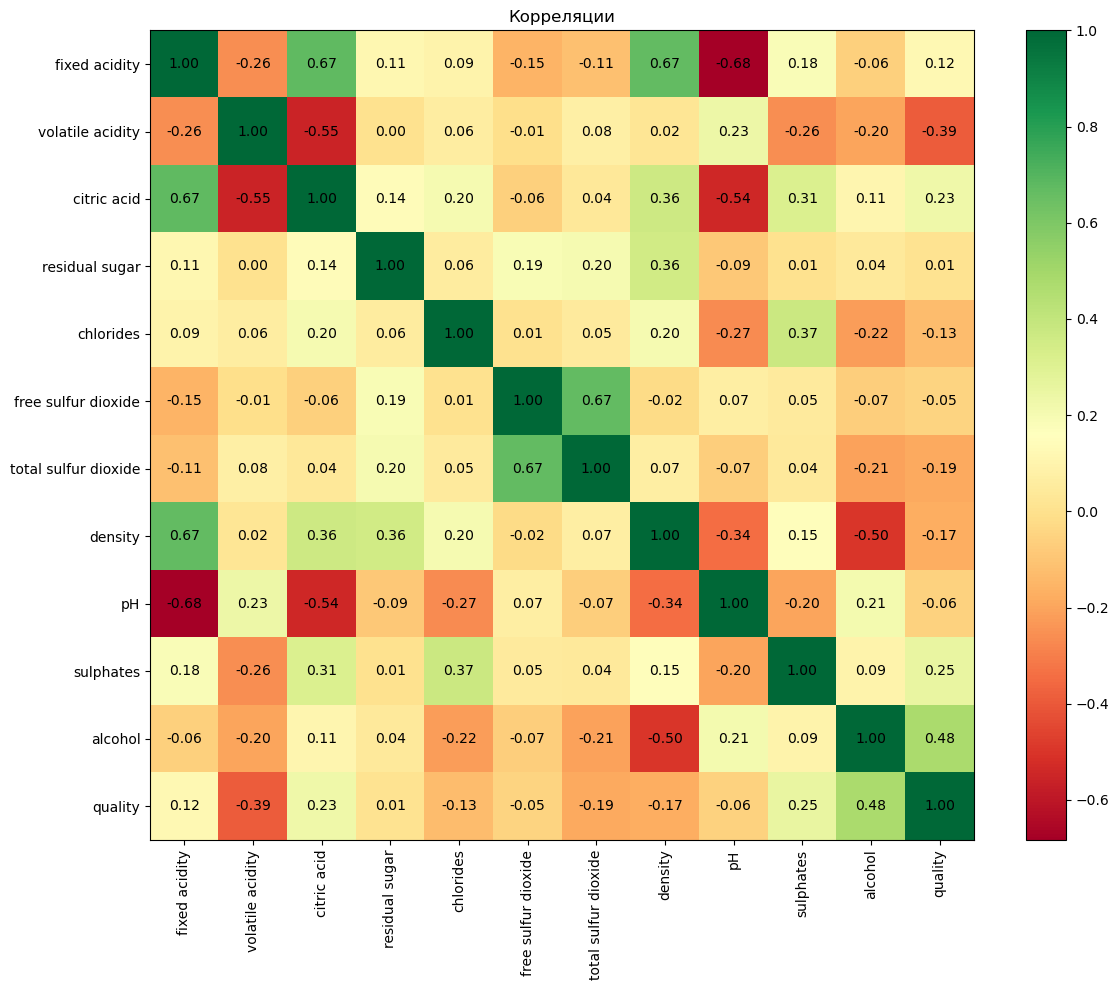

In [37]:
import matplotlib.pyplot as plt

#Вычислям матрицу корреляций между всеми числовыми переменными в наборе данных
correlation_matrix = data.select_dtypes(include=[np.number]).corr() 

plt.figure(figsize=(12, 10))
plt.imshow(correlation_matrix, cmap='RdYlGn', interpolation='none', aspect='auto') # построение тепловой карты
plt.colorbar()

#Размещаем названия переменных на осях X и Y , поворачиваем подписи на 90 для лучшей читаемости
ticks = range(len(correlation_matrix.columns))
plt.xticks(ticks, correlation_matrix.columns, rotation=90)
plt.yticks(ticks, correlation_matrix.columns)

#Проходимся по всем колонкам и в блоки записываем их корреляции
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}", ha='center', va='center', color='black')

plt.title("Корреляции")
plt.tight_layout()
plt.show()

In [38]:
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_data = data.select_dtypes(include=[np.number])
X = add_constant(numeric_data)

# Расчет VIF для каждой переменной
vif_data = pd.DataFrame({
    "Переменная": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# Фильтруем данные, исключая const
vif_data_filtered = vif_data[vif_data['Переменная'] != 'const']

print("\n РЕЗУЛЬТАТЫ VIF АНАЛИЗА:")

for _, row in vif_data_filtered.iterrows():
    variable = row['Переменная']
    vif = row['VIF']
    
    # Определяем статус на основе значения VIF
    if vif == 1:
        status = "Идеально"
    elif vif < 5:
        status = "Норма"
    elif vif < 10:
        status = "Внимание"
    else:
        status = "Проблема"
    # Форматируем вывод
    var_name = variable[:25] + "..." if len(variable) > 25 else variable
    print(f"   | {var_name:30} | {vif:8.2f}   | {status:19} |")

vif_data_no_const = vif_data[vif_data['Переменная'] != 'const']
perfect_count = len(vif_data_no_const[vif_data_no_const['VIF'] == 1])
good_count = len(vif_data_no_const[(vif_data_no_const['VIF'] > 1) & (vif_data_no_const['VIF'] < 5)])
warning_count = len(vif_data_no_const[(vif_data_no_const['VIF'] >= 5) & (vif_data_no_const['VIF'] < 10)])
problem_count = len(vif_data_no_const[vif_data_no_const['VIF'] >= 10])


 РЕЗУЛЬТАТЫ VIF АНАЛИЗА:
   | fixed acidity                  |     7.77   | Внимание            |
   | volatile acidity               |     1.88   | Норма               |
   | citric acid                    |     3.13   | Норма               |
   | residual sugar                 |     1.70   | Норма               |
   | chlorides                      |     1.50   | Норма               |
   | free sulfur dioxide            |     1.97   | Норма               |
   | total sulfur dioxide           |     2.21   | Норма               |
   | density                        |     6.35   | Внимание            |
   | pH                             |     3.34   | Норма               |
   | sulphates                      |     1.49   | Норма               |
   | alcohol                        |     3.24   | Норма               |
   | quality                        |     1.56   | Норма               |


<b>Выводы:</b>
1. Умеренная мультиколлинеарность наблюдается в переменных "fixed acidity" (VIF = 7.77) и "density" (VIF = 6.35). Это объясняется тем, что фиксированная кислотность и плотность вина являются взаимосвязанными физико-химическими параметрами, которые зависят от состава сусла и процесса брожения.
2. Низкий VIF (менее 5) у остальных переменных - "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "pH", "sulphates", "alcohol" и "quality" - подтверждает их относительную независимость в модели и отсутствие серьезных проблем мультиколлинеарности.
3. Общий уровень мультиколлинеарности в данных можно считать приемлемым для построения регрессионных моделей, так как значения VIF не превышают критического порога 10.

## 5.Исследование зависимости в данных с помощью дисперсионного анализа.

**ANOVA (Analysis of Variance)** - статистический метод для сравнения средних значений трёх или более групп. Используется для проверки гипотезы о наличии статистически значимых различий между групповыми средними.

**Ключевые гипотезы:**
- **Нулевая гипотеза (H₀):** Все групповые средние равны (μ₁ = μ₂ = ... = μₖ)
- **Альтернативная гипотеза (H₁):** Хотя бы одно групповое среднее отличается от остальных

**Основные предположения:**
1. **Независимость наблюдений** - данные в разных группах независимы
2. **Нормальность распределения** - данные в каждой группе распределены нормально
3. **Однородность дисперсий** - дисперсии во всех группах равны (гомоскедастичность)

**Интерпретация результатов:**
- **F-статистика:** Показывает отношение вариации между группами к вариации внутри групп
- **p-value:** Вероятность получить наблюдаемые различия при условии, что H₀ верна
- **Правило принятия решения:** Если p-value < 0.05, отвергаем H₀ (различия значимы)

**В данном анализе:** ANOVA используется для проверки влияния содержания алкоголя (разделённого на категории: 8-10%, 10-12%, 12-14%, 14-16%) на плотность вина.

In [39]:
from scipy.stats import f_oneway

# Создаем категории для алкоголя
bins = [8, 10, 12, 14, 16]
labels = ['8-10%', '10-12%', '12-14%', '14-16%']
data['alcohol_category'] = pd.cut(data['alcohol'], bins=bins, labels=labels)

# Проводим ANOVA анализ
groups = [group['density'] for _, group in data.groupby('alcohol_category', observed=False)]
anova_result = f_oneway(*groups)

# Красивый вывод результатов
print(f"\n                 РЕЗУЛЬТАТЫ ANOVA ТЕСТА:")
print(f"   | F-статистика        | {anova_result.statistic:15.2f}             |")
print(f"   | P-значение          | {anova_result.pvalue:15.2e}             |")


                 РЕЗУЛЬТАТЫ ANOVA ТЕСТА:
   | F-статистика        |          137.91             |
   | P-значение          |        1.93e-79             |


<b>Вывод:</b>
- <b>Высокое значение F-статистики (137.91)</b> свидетельствует о наличии существенных различий в средней плотности вин между различными алкогольными категориями.
- <b>Экстремально низкое p-value (1.93 × 10<sup>-79</sup>)</b> значительно ниже общепринятого уровня значимости 0.05, что дает основание отвергнуть нулевую гипотезу о равенстве средних значений плотности во всех группах.
- Статистический анализ подтверждает, что категоризация вин по содержанию алкоголя позволяет выделить группы с достоверно различными показателями плотности. Наблюдается четкая физико-химическая закономерность: увеличение концентрации алкоголя, имеющего меньшую плотность по сравнению с водой, приводит к снижению общей плотности вина.

## 6.Подогнать регрессионные модели (в том числе, нелинейные) к данным, а также оценить качество подобной аппроксимации.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error

# Выбираем переменные для регрессионного анализа
filtered_data = data[['quality', 'alcohol', 'density', 'volatile acidity', 'citric acid']]

# Определяем признаки (X) и целевую переменную (y)
X = filtered_data[['alcohol', 'density', 'volatile acidity', 'citric acid']]
y = filtered_data['quality']

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем линейную регрессию
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

# Обучаем полиномиальную регрессию (степень 3)
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

# Вычисляем метрики для обеих моделей
linear_r2 = r2_score(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)

poly_r2 = r2_score(y_test, y_pred_poly)
poly_mse = mean_squared_error(y_test, y_pred_poly)

print("          СРАВНЕНИЕ ЛИНЕЙНОЙ И ПОЛИНОМИАЛЬНОЙ РЕГРЕССИИ")

print("   | Модель                     | R2 Score     | MSE            |")
print("   |                            |              |                |")
print(f"   | Линейная регрессия         | {linear_r2:12.4f} | {linear_mse:14.4f} │")
print(f"   | Полиномиальная (степень 3) | {poly_r2:12.4f} | {poly_mse:14.4f} │")

          СРАВНЕНИЕ ЛИНЕЙНОЙ И ПОЛИНОМИАЛЬНОЙ РЕГРЕССИИ
   | Модель                     | R2 Score     | MSE            |
   |                            |              |                |
   | Линейная регрессия         |       0.3619 |         0.4170 │
   | Полиномиальная (степень 3) |       0.3404 |         0.4310 │


<b>Вывод:</b>
В отличие от ожиданий, полиномиальная модель (степень = 3) <span style="color:red">уступает</span> линейной модели по точности (R²: 0.3404 vs 0.3619) и ошибке (MSE: 0.4310 vs 0.4170). Низкие значения R² обеих моделей (< 0.4) свидетельствуют о слабой объясняющей способности и требуют применения других подходов к моделированию данных.
